# MNIST Image Classification with a Convolutional Neural Network (CNN) in PyTorch

This notebook demonstrates how to build and train a simple CNN using PyTorch to classify handwritten digits from the MNIST dataset. It covers essential steps from data loading and preprocessing to model definition, training, and evaluation.

## Table of Contents

1.  [Setting up the Environment and Loading Data](#section1)
    *   1.1 Imports
    *   1.2 Device Management
    *   1.3 Data Loading & Transformations
    *   1.4 Preparing Data with DataLoaders
2.  [Defining the Model Architecture](#section2)
    *   2.1 CNN Class
    *   2.2 Model Instantiation and Parameter Count
3.  [Loss Function and Optimizer](#section3)
    *   3.1 Loss Function (`nn.CrossEntropyLoss`)
    *   3.2 Optimizer (`torch.optim.Adam`)
4.  [Implementing the Training Loop](#section5)
    *   4.1 Epoch and Batch Processing
    *   4.2 Tracking Metrics
5.  [Performance Evaluation](#section6)
    *   5.1 Visualizing Training Progress
    *   5.2 Final Test Set Evaluation
    *   5.3 Confusion Matrix Analysis

<a id='section1'></a>
## 1. Setting up the Environment and Loading Data

### 1.1 Imports

This section begins by importing all necessary libraries for our MNIST classification task. We use:

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

### 1.2 Device Management

In [2]:
# Determine if GPU is available and set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### 1.3 Data Loading & Transformations

In [3]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(root='../Data', train=True, download=True, transform=transform)

test_data = datasets.MNIST(root='../Data', train=False, download=True, transform=transform)

print(train_data)
print(test_data)


Dataset MNIST
    Number of datapoints: 60000
    Root location: ../Data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: ../Data
    Split: Test
    StandardTransform
Transform: ToTensor()


### 1.4 Preparing Data with DataLoaders

In [4]:
torch.manual_seed(101) #for reproducibility


# start with small batchsizes and
# then check out larger batch sizes
# it all depends on your hardware
batchsize_train = 60
train_loader = DataLoader(train_data, batch_size=batchsize_train, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batchsize_train, shuffle=False)

## 2. Model Architecture

we do not need to put pooling layeres inside the init method. we can treat them just like activations (pooling activation rather than pooling layer) and just use them in the forward method.

### 2.1 ConvolutionalNetwork Class

In [5]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3, 1) #(in_channel, out_chennel, kernel, stride)
        self.conv2 = nn.Conv2d(6, 16, 3, 1)

        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)
        X = X.view(-1, 5*5*16) #FLATTEN
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)

        return X

conv: reduces the input size by 2

pooling: divide the input size by 2.
its output is just like the previous conv layer >> just reduces the number of parameters by subsampling or downsampling the feature map

((28-2)/2 - 2)/2

### 2.2 Model Instantiation and Parameter Count

In [6]:
model = ConvolutionalNetwork()
model.to(device) # Move the model to the selected device
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [7]:
for param in model.parameters():
    print(param.numel())

54
6
864
16
48000
120
10080
84
840
10


## 3. Loss Function and Optimizer

In [8]:
criterion = nn.CrossEntropyLoss() # for multi-class classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

increase lr >> risk of overfitting to the training data, never converging

## 4. Implementing the Training Loop

In [10]:
import time
start_time = time.time()

# TRAINING
epochs = 3


# TRACKERS per epoch
train_losses = []
test_losses = []
train_acc = [] # Now stores epoch-level training accuracy
test_acc = []  # Now stores epoch-level test accuracy



for i in range(epochs):

    trn_corr_sum = 0 # Accumulator for correct predictions in training
    tst_corr_sum = 0 # Accumulator for correct predictions in testing
    trn_loss = 0
    tst_loss = 0

    # Training loop
    for batch_idx, (x_train, y_train) in enumerate(train_loader):
        batch_idx += 1

        # Move data to the selected device
        x_train, y_train = x_train.to(device), y_train.to(device)

        y_pred = model(x_train)
        loss = criterion(y_pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Convert predicted probabilities to labels
        predicted = torch.max(y_pred.detach(), 1).indices
        batch_corr = (predicted == y_train).sum()
        trn_corr_sum += batch_corr.item()
        trn_loss += loss.item()

        if batch_idx % 200 == 0:
            batch_acc = batch_corr.item() / x_train.size(0)
            print(f'Epoch {i:2} Batch {batch_idx:3} | Training Loss: {loss.item():10.8f} | Training Accuracy: {batch_acc:7.4f}')

    # End of training epoch calculations
    train_losses.append(trn_loss / len(train_loader)) # Average loss per batch for the epoch
    train_acc.append(trn_corr_sum / len(train_data)) # Store epoch-level training accuracy

    # Validation loop
    with torch.no_grad():
        for batch_idx, (x_test, y_test) in enumerate(test_loader):
            # Move data to the selected device
            x_test, y_test = x_test.to(device), y_test.to(device)

            y_val = model(x_test)
            loss = criterion(y_val, y_test)

            predicted_test = torch.max(y_val.detach(), 1).indices
            tst_corr_sum += (predicted_test == y_test).sum().item()
            tst_loss += loss.item()

            # Print batch-level validation accuracy for every 10th batch
            if batch_idx % 40 == 0: # Test loader has fewer batches, so smaller modulo for print
                test_batch_acc = (predicted_test == y_test).sum().item() / x_test.size(0)
                print(f'                               Test Batch {batch_idx:3} | Validation Loss: {loss.item():10.8f} | Validation Accuracy: {test_batch_acc:7.4f}')


    # End of validation epoch calculations
    test_losses.append(tst_loss / len(test_loader)) # Average loss per batch for the epoch
    test_acc.append(tst_corr_sum / len(test_data)) # Store epoch-level test accuracy

    print(f'Epoch {i:2} Summary: Training Loss: {train_losses[-1]:10.8f} | Training Accuracy: {train_acc[-1]:7.4f} | Validation Loss: {test_losses[-1]:10.8f} | Validation Accuracy: {test_acc[-1]:7.4f}\n')


total_time = time.time() - start_time
print(f'Duration: {total_time/60:.2f} minutes')

Epoch  0 Batch 200 | Training Loss: 0.45942676 | Training Accuracy:  0.8500
Epoch  0 Batch 400 | Training Loss: 0.27533376 | Training Accuracy:  0.8833
Epoch  0 Batch 600 | Training Loss: 0.22077090 | Training Accuracy:  0.9500
Epoch  0 Batch 800 | Training Loss: 0.11593963 | Training Accuracy:  0.9833
Epoch  0 Batch 1000 | Training Loss: 0.03174354 | Training Accuracy:  0.9833
                               Test Batch   0 | Validation Loss: 0.03460152 | Validation Accuracy:  0.9833
                               Test Batch  40 | Validation Loss: 0.15606213 | Validation Accuracy:  0.9333
                               Test Batch  80 | Validation Loss: 0.20676889 | Validation Accuracy:  0.9500
                               Test Batch 120 | Validation Loss: 0.06509788 | Validation Accuracy:  1.0000
                               Test Batch 160 | Validation Loss: 0.13255633 | Validation Accuracy:  0.9500
Epoch  0 Summary: Training Loss: 0.35574700 | Training Accuracy:  0.8890 | Validatio

## 5. Performance Evaluation

### 5.1 Visualizing Training Progress

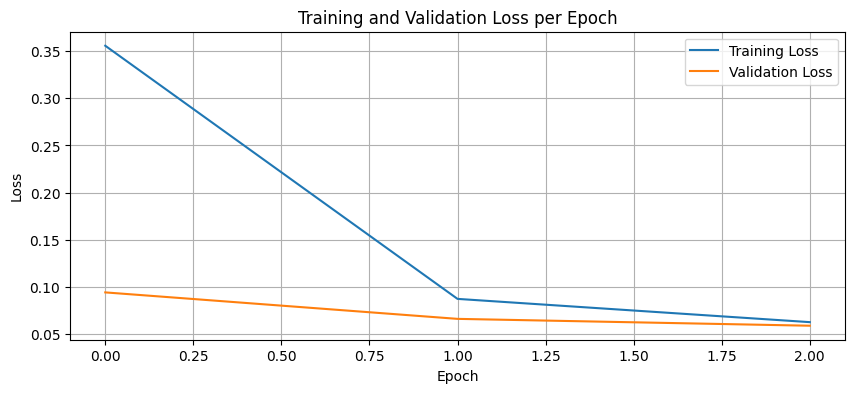

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses.cpu(), label='Training Loss')
plt.plot(test_losses.cpu(), label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

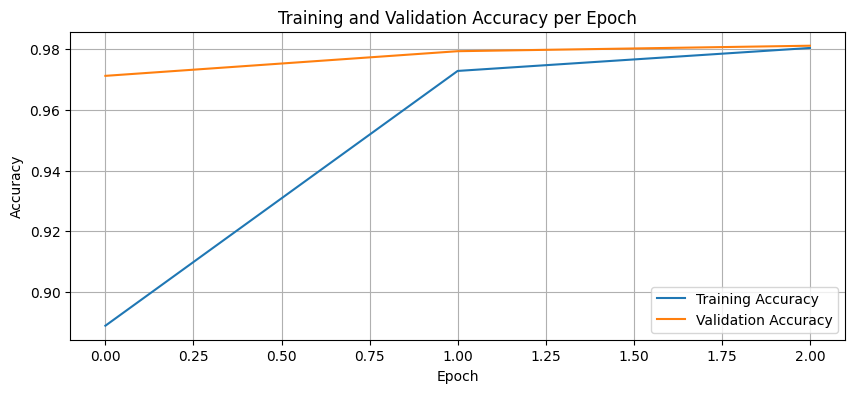

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(train_acc, label='Training Accuracy')
plt.plot(test_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy per Epoch')
plt.legend()
plt.grid(True)
plt.show()

Based on the accuracy plot and the values for `train_acc` and `test_acc`:

* Epoch 0: Training Accuracy: ~88.9%, Validation Accuracy: ~97.1%
* Epoch 1: Training Accuracy: ~97.3%, Validation Accuracy: ~97.9%
* Epoch 2: Training Accuracy: ~98.0%, Validation Accuracy: ~98.1%
Interpretation:

The plot shows that both the training and validation accuracies are consistently increasing and are very close to each other across the three epochs. By the final epoch, both accuracies are very high (around 98%). This indicates that your model is learning effectively and generalizing well to unseen data. There's no significant gap between training and validation accuracy, which means the model is not overfitting.

Why accuracy on test set is better than the validation set?
* **Timing of Evaluation**: The training accuracy (`train_acc`) aggregates performance while the model's weights *are actively changing and optimizing* throughout the training batches. The validation accuracy (`test_acc`) is calculated using the model's weights *after all training for that epoch is done*, representing a more stable and potentially optimized state for that epoch.
* **Dataset Characteristics**: Even without explicit regularization like dropout, it's possible that your test set, by chance, contains samples that are slightly easier for the model to classify, leading to a marginally higher accuracy. This is particularly noticeable when accuracies are already very high (like your 97-98%)

### 5.2 Final Test Set Evaluation

In [14]:
test_load_all = DataLoader(test_data, batch_size=10000, shuffle=False)

with torch.no_grad():
    correct = 0

    for x_test, y_test in test_load_all:
       # Move data to the selected device
       x_test, y_test = x_test.to(device), y_test.to(device)

       y_val = model(x_test)
       predicted = torch.max(y_val, 1)[1]
       correct += (y_test == predicted).sum().item()

acc_test = correct/len(test_data)

In [15]:
acc_test

0.981

recall that our ANN network returned an acuracy of 97%, after 10 epochs. However, it had to use up to 100,000 parameters and here we used around 60,000 with 3 epochs of training >> we are doing better (98%) with less parameters.

In [16]:
test_data[2019]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

tensor(9, device='cuda:0')

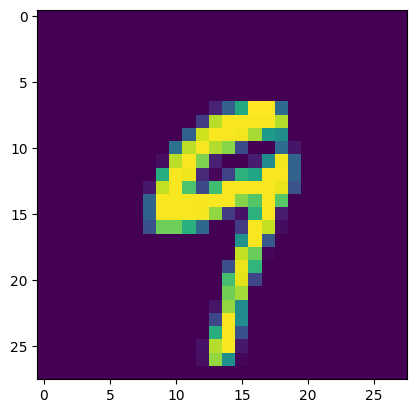

In [17]:
plt.imshow(test_data[2019][0].reshape((28, 28)))

model.eval()
with torch.no_grad():
    new_prediction = model(test_data[2019][0].view(1, 1, 28, 28).to(device))
new_prediction.argmax()

### 5.3 Confusion Matrix Analysis

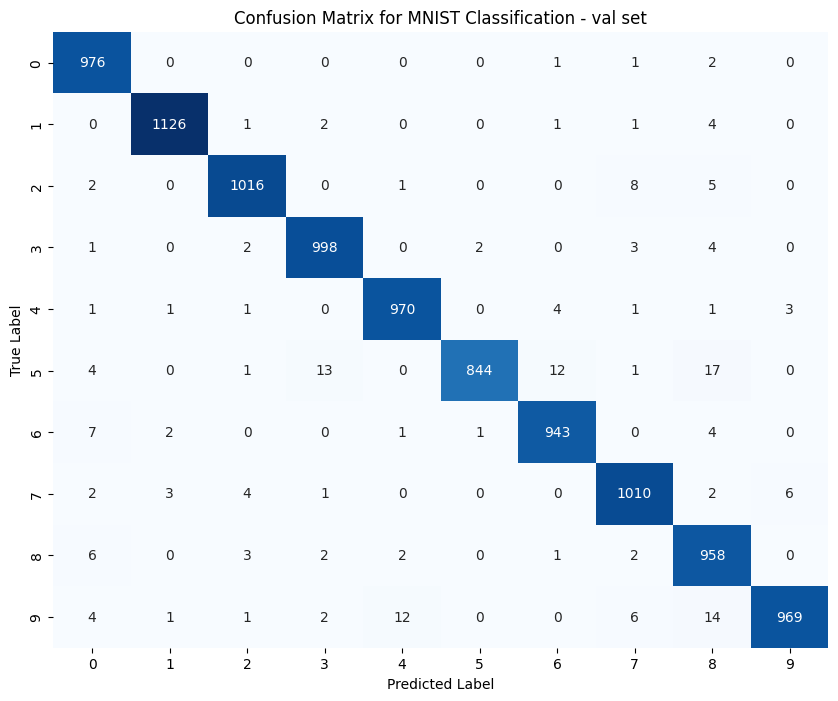

In [20]:
import seaborn as sns

# Assuming 'predicted' and 'y_test' are available from the previous cell
cm = confusion_matrix(y_test.cpu(), predicted.cpu())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for MNIST Classification - val set')
plt.show()